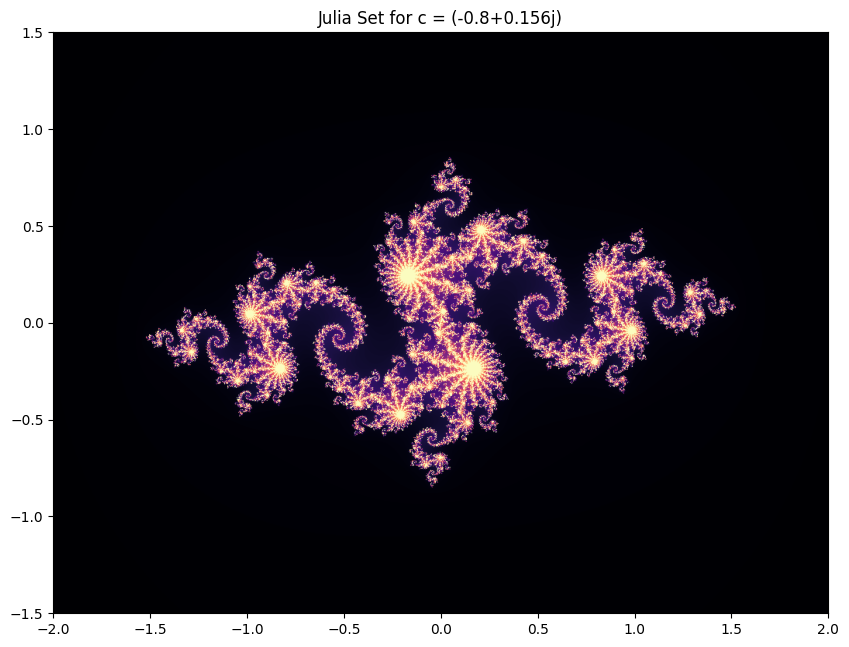

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

# 1. Define the map using Numba for speed
# This decorator compiles the function to machine code
@jit(nopython=True)
def julia_set(width, height, x_min, x_max, y_min, y_max, c, max_iter):
    # Create the image array
    image = np.zeros((height, width))
    
    # Setup the grid steps
    dx = (x_max - x_min) / width
    dy = (y_max - y_min) / height
    
    for y in range(height):
        for x in range(width):
            # Map pixel coordinate to complex plane
            real = x_min + x * dx
            imag = y_min + y * dy
            z = complex(real, imag)
            
            # Iteration of Rational Function (e.g., z^2 + c)
            iter_count = 0
            while abs(z) <= 2 and iter_count < max_iter:
                z = z*z + c
                iter_count += 1
            
            image[y, x] = iter_count
            
    return image

# 2. Parameters
w, h = 1000, 1000
c_val = complex(-0.8, 0.156) # A nice parameter for Julia Set

# 3. Run the function
result = julia_set(w, h, -2.0, 2.0, -1.5, 1.5, c_val, 256)

# 4. Plot
plt.figure(figsize=(10, 10))
plt.imshow(result, cmap='magma', extent=[-2, 2, -1.5, 1.5])
plt.title(f"Julia Set for c = {c_val}")
plt.show()

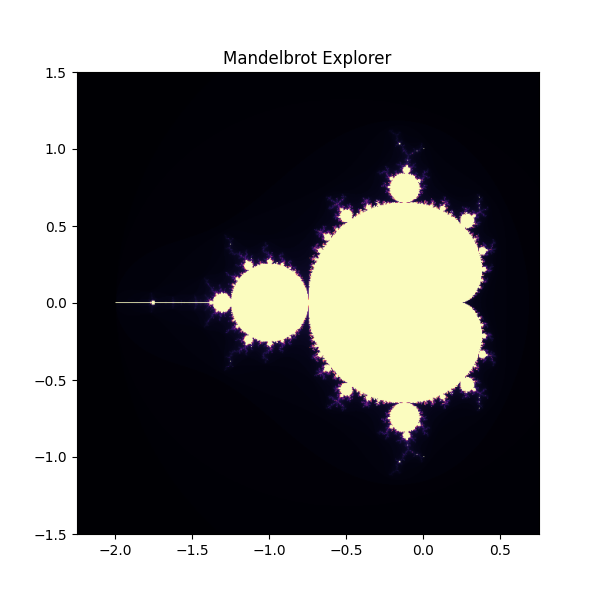

In [3]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from numba import jit, prange
import ipywidgets as widgets
from IPython.display import display

# We add 'parallel=True' to use all cores of your M3
@jit(nopython=True, parallel=True)
def mandelbrot_numpy(x_min, x_max, y_min, y_max, width, height, max_iter):
    # 1. Create the empty result array
    div_time = np.zeros((height, width), dtype=np.int32)
    
    # 2. Calculate the step size for the grid
    dx = (x_max - x_min) / width
    dy = (y_max - y_min) / height
    
    # 3. Explicit loops (Numba loves these)
    # prange allows Numba to run this loop on multiple CPU cores in parallel
    for y in prange(height):
        for x in range(width):
            # Map pixel (x, y) to complex plane (real, imag)
            real = x_min + x * dx
            imag = y_min + y * dy
            c = complex(real, imag)
            z = 0.0 + 0.0j
            
            # Per-pixel iteration
            iter_count = 0
            while iter_count < max_iter:
                # Optimized check: Avoid square root (abs) by comparing squares
                if (z.real * z.real + z.imag * z.imag) > 4.0:
                    break
                z = z*z + c
                iter_count += 1
            
            div_time[y, x] = iter_count
            
    return div_time

# 2. The Interactive Wrapper
def interactive_fractal():
    # Setup Parameters
    w, h = 600, 600       # Slightly safer resolution
    max_iter = 200        # Iteration limit
    
    # Setup Figure
    # We explicitly set vmin=0 and vmax=max_iter so the colors don't drift
    plt.close('all')      # Close old plots to save memory
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Initialize with dummy data (all zeros)
    # vmin=0 (Black), vmax=max_iter (Bright Yellow)
    img_display = ax.imshow(np.zeros((h, w)), 
                            origin='lower', 
                            cmap='magma', 
                            vmin=0, 
                            vmax=max_iter) 
    
    ax.set_title("Mandelbrot Explorer")
    
    # State Dictionary
    state = {'x': -0.75, 'y': 0.0, 'zoom': 1.0}

    def update_plot(btn=None):
        # 1. Calculate Coordinates
        radius = 1.5 / state['zoom']
        x_min = state['x'] - radius
        x_max = state['x'] + radius
        y_min = state['y'] - radius
        y_max = state['y'] + radius
        
        # 2. Run Numba Calculation
        fractal = mandelbrot_numpy(x_min, x_max, y_min, y_max, w, h, max_iter)
        
        # 3. Update the Plot
        img_display.set_data(fractal)
        img_display.set_extent([x_min, x_max, y_min, y_max])
        fig.canvas.draw_idle()

    # Controls
    zoom_slider = widgets.FloatLogSlider(value=1.0, base=10, min=0, max=8, description='Zoom')
    x_slider = widgets.FloatSlider(value=-0.75, min=-2.5, max=1.0, step=0.01, description='X')
    y_slider = widgets.FloatSlider(value=0.0, min=-1.5, max=1.5, step=0.01, description='Y')
    render_btn = widgets.Button(description="Refresh")

    # Event Handlers
    def on_change(change):
        if change['name'] == 'value':
            if change['owner'] == zoom_slider: state['zoom'] = change['new']
            if change['owner'] == x_slider: state['x'] = change['new']
            if change['owner'] == y_slider: state['y'] = change['new']
            update_plot()

    zoom_slider.observe(on_change)
    x_slider.observe(on_change)
    y_slider.observe(on_change)
    render_btn.on_click(update_plot)

    # Initial Draw
    update_plot()
    
    # Layout
    ui = widgets.VBox([
        widgets.HBox([x_slider, y_slider]),
        zoom_slider,
        render_btn
    ])
    display(ui)

interactive_fractal()